In [ ]:
#Pillow
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

tokyo_tower = Image.open("tokyo_tower.png")  #pillowasで画像読み込み
color_image = np.array(tokyo_tower)  #ndarray に変換
print(type(color_image))  #ndarray に変換されたこと確認。
print(color_image.shape)  #ndarray に変換されたこと確認。
 #出力される３、はRGB（赤緑青）それぞれの値の濃さが入っていることを示す
print(color_image[0, 0, :]) #3番目はコロンにすることでRGBそれぞれの値を取得できる
color_image[0, 0, :]  #→座標0,0左上橋のピクセル情報
#  array([116, 166, 218], dtype=uint8)




<class 'numpy.ndarray'>
(750, 500, 3)
[116 166 218]


array([116, 166, 218], dtype=uint8)

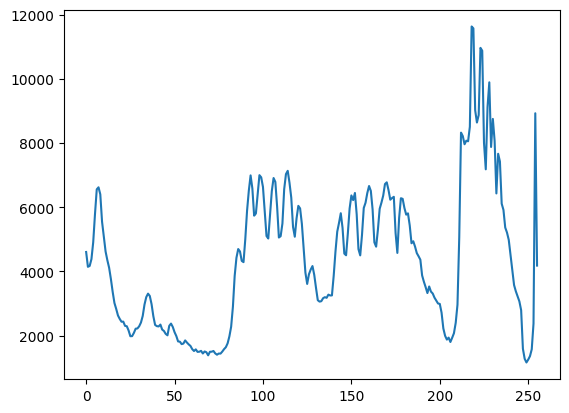

In [ ]:
#AIが学習する画像データは数値。
#明るさ分布、ヒストグラムもその一つ。

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

tokyo_tower = Image.open("tokyo_tower.png")  #pillowasで画像読み込み
color_image = np.array(tokyo_tower)  #ndarray に変換

hist_c, bins_c = np.histogram(color_image.flatten(), bins=256)
#flattern()はNumPy配列を一次元に変換（平坦化）するメソッド
plt.plot(hist_c)
plt.show()




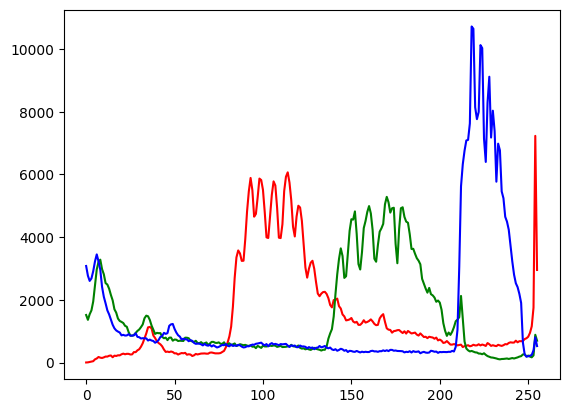

In [7]:
#AIが学習する画像データは数値。
#明るさ分布、ヒストグラムもその一つ。
#スライスを使うことで、RGB各色のヒストグラムを表示。

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

tokyo_tower = Image.open("tokyo_tower.png")  #pillowasで画像読み込み
color_image = np.array(tokyo_tower)  #ndarray に変換

#スライスを使うことで、RGB各色のヒストグラムを表示。
#引数にナンバリングすることで回数分繰り返す
for i, color in enumerate(["red", "green", "blue"]):
    hist_x, bins_x = np.histogram(color_image[:, :, i], bins=256)
    plt.plot(hist_x, color=color) 
    #素人に思いつかないやり方・・・
plt.show()



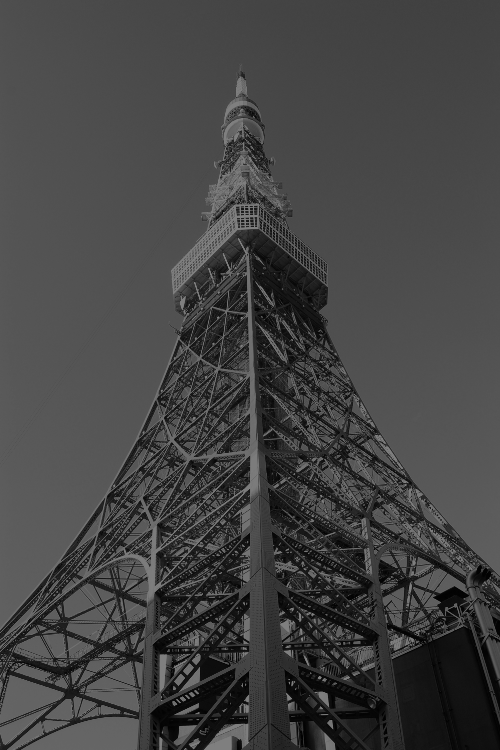

In [ ]:
#ndarray形式の画像の表示
#つまり、画像をndarrayの数値計算で加工

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

tokyo_tower = Image.open("tokyo_tower.png")  #pillowasで画像読み込み
color_image = np.array(tokyo_tower)  #ndarray に変換

#ndarrayに変換されたものを画像に戻す。には：
color_pil =Image.fromarray(np.uint8(color_image)) # uint8型は0～255

#　画像をndarrayで暗く加工して画像に戻し、さらに白黒にしている↓
half_image = color_image // 2
half_image = Image.fromarray(np.uint8(half_image))
half_image = half_image.convert("L")
half_image

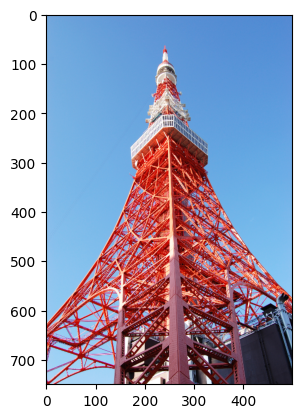

In [12]:
#番外編、Matplotlibでも画像は表示できる

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

tokyo_tower = Image.open("tokyo_tower.png")  #pillowasで画像読み込み
plt.imshow(color_image)
plt.show()

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt #pillowで画像を読めるように

#画像読みこむ
soft_org = Image.open("soft.png")
#ndarrayに変換したデータを作る
soft_org_array = np.array(soft_org)


In [5]:
#なおPillows で読んだ画像は、ﾒｿｯﾄﾞでプロパティもわかる
print(soft_org.width)
print(soft_org.height)
print(soft_org.size)

180
180
(180, 180)


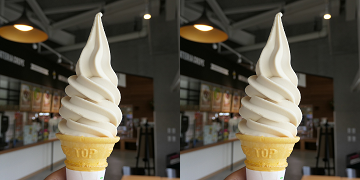

In [7]:
#画像の連結　
# 土台の作成
#（new()の最初の引数は色空間の指定、
# 2つ目の引数は(幅, 高さ)のタプル）
soft2 = Image.new("RGB", (soft_org.width * 2, soft_org.height))

# 画像の貼り付け
#（paste()の最初の引数は貼り付ける画像、2つ目の引数は左上の座標(横, 縦)のタプル）
soft2.paste(soft_org, (0, 0))
soft2.paste(soft_org, (soft_org.width, 0))

# 新しい画像の表示
soft2

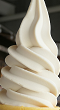

In [27]:
#画像の切り抜き
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt #pillowで画像を読めるように

#画像読みこむ
soft_org = Image.open("soft.png")
#ndarrayに変換したデータを作る
soft_org_array = np.array(soft_org)


# クリームの部分の切り抜き
soft_crop = soft_org.crop((60, 30, 120, 140))

# 切り抜いた画像の表示
soft_crop


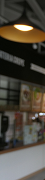

In [19]:
soft_crop_list = []
for i in range(4):
    soft_crop_list.append(soft_org.crop((45*i, 0, 45 * (i+1), soft_org.height)))

# 左端の画像のみ表示
soft_crop_list[0]

In [ ]:
# 分割した画像をGIFアニメーションとして保存

#save() で指定のキーワード引数を追加することで
#複数の画像を「GIF形式のアニメーション画像のファイル」として保#
soft_crop_list[0].save("soft_anim.gif",
                       save_all=True,
                       append_images=soft_crop_list[1:4],
                       loop=0,
                       duration=500)